<a href="https://colab.research.google.com/github/Aman-5011/ML_100days_campusx/blob/main/day%2051%20Gradient%20Descent/GD1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
from sklearn.datasets import make_regression
import numpy as np

In [55]:
x,y = make_regression(n_samples=4 , n_features=1 , n_informative=1 , n_targets=1 , noise=80 , random_state=13)
#n_informative How many features actually affect the output.

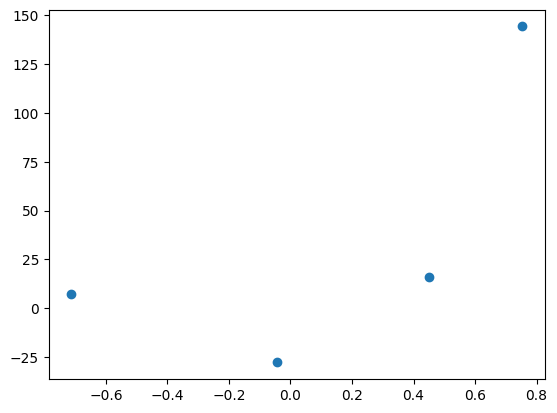

In [56]:
import matplotlib.pyplot as plt
plt.scatter(x,y)

In [57]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(x, y)
print(reg.coef_)
print(reg.intercept_)

[78.35063668]
26.15963284313262


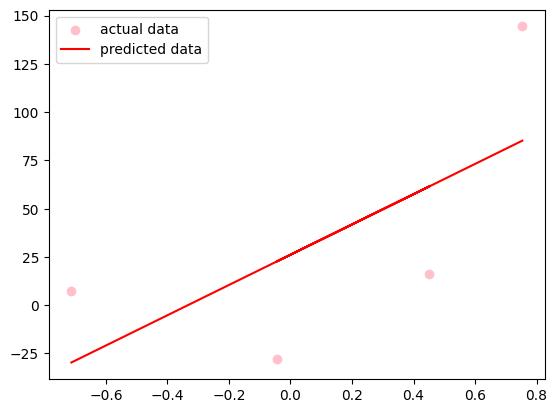

In [58]:
plt.scatter(x,y,color='pink' , label='actual data') #scatter shows point
plt.plot(x, reg.predict(x),color='red' , label='predicted data') #but plot connects all the points
plt.legend() #bel box that tells which plot is which. works only if you add levels

In [59]:
#lets apply gd assuming slope is constant m=78.35
#lets assume the starting value for intercept b=100
y_pred=((78.35*x+100)).reshape(4)

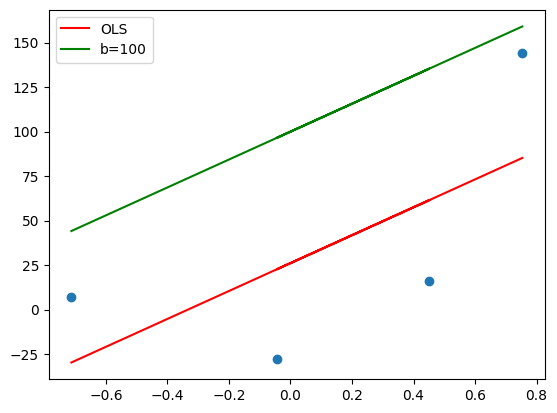

In [60]:
plt.scatter(x,y)
plt.plot(x, reg.predict(x), color='red',label='OLS')
plt.plot(x, y_pred, color='green' ,label='b=100')
plt.legend()


In [61]:
#wrong answer
m=78.35
b=100
loss_slope=-2*np.sum(y-m*x-b)
print(loss_slope)
#here size of y is 4 1d and size of x is (4,1) 2d so due to broadcasting y become (1,4)
#broadcasting = Broadcasting is NumPy’s rule that lets arrays of different shapes do arithmetic by automatically expanding the smaller one to match the bigger one.

2362.8894636716313


In [62]:
m=78.35
b=100
loss_slope=-2*np.sum(y-m*x.flatten()-b)
print(loss_slope)

590.7223659179078


In [63]:
# Both **`ravel()`** and **`flatten()`** convert an array into a 1D vector.
# `ravel()` returns a view (shares memory) while `flatten()` returns a copy (new memory).


In [64]:
lr=0.1
b=b-lr*loss_slope
b

np.float64(40.927763408209216)

In [65]:
y_pred1=(m*x+b).reshape(4)

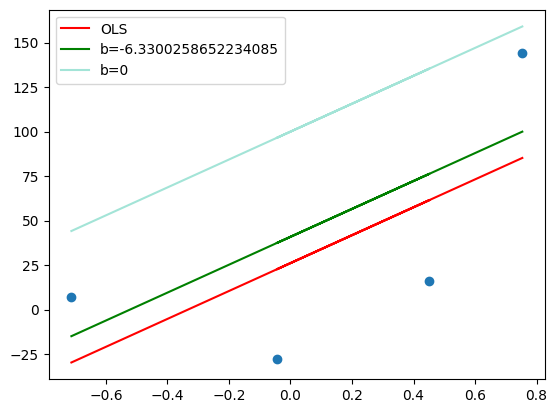

In [73]:
plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='red',label='OLS')
plt.plot(x,y_pred1 , color='green',label='b={}'.format(b)) #format() inserts variables into a string using {} placeholders.
plt.plot(x,y_pred,color='#a3e4d7' ,label='b=0')
plt.legend()

In [74]:
# Iteration 2
loss_slope = -2 * np.sum(y - m*x.ravel() - b)
loss_slope

np.float64(-259.9178410038794)

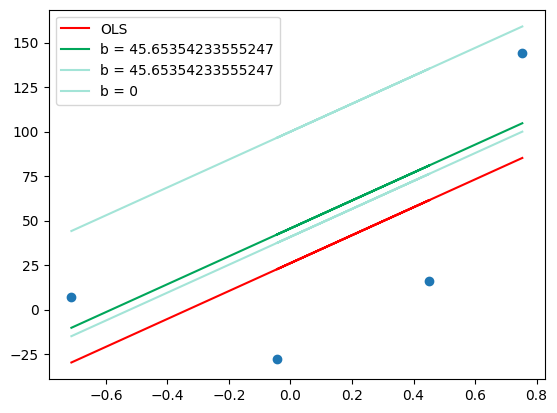

In [76]:

step_size = loss_slope*lr
step_size

b = b - step_size


y_pred2 = ((78.35 * x) + b).reshape(4)

plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='red',label='OLS')
plt.plot(x,y_pred2,color='#00a65a',label='b = {}'.format(b))
plt.plot(x,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(x,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

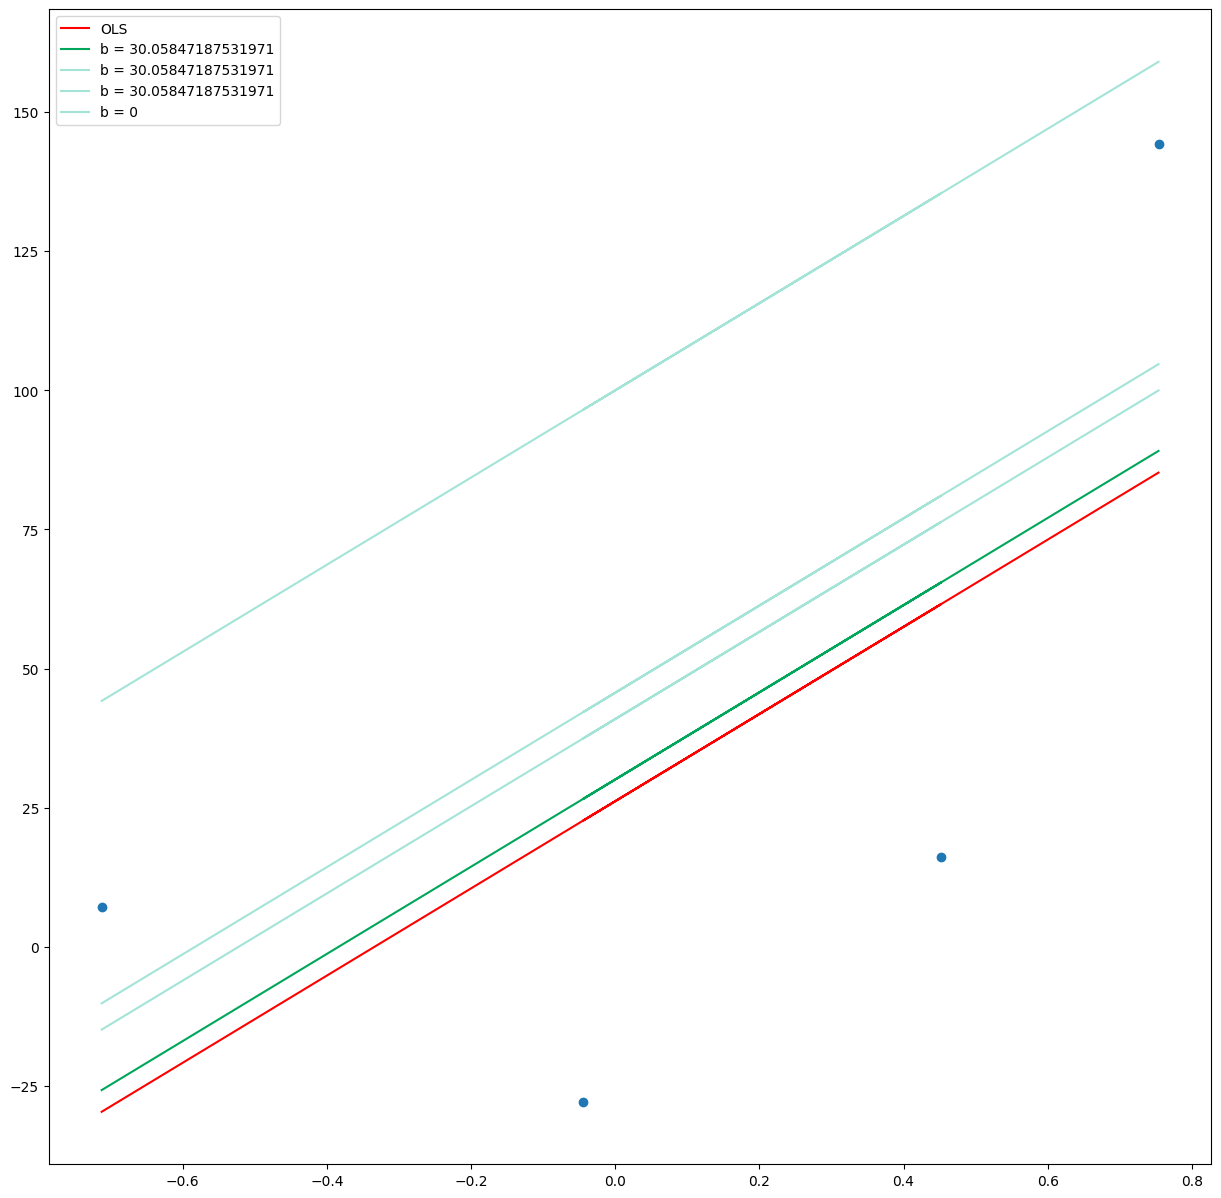

In [77]:
X=x

# Iteration 3
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope
step_size = loss_slope*lr
step_size
b = b - step_size

y_pred3 = ((78.35 * X) + b).reshape(4)

plt.figure(figsize=(15,15))
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred3,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred2,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

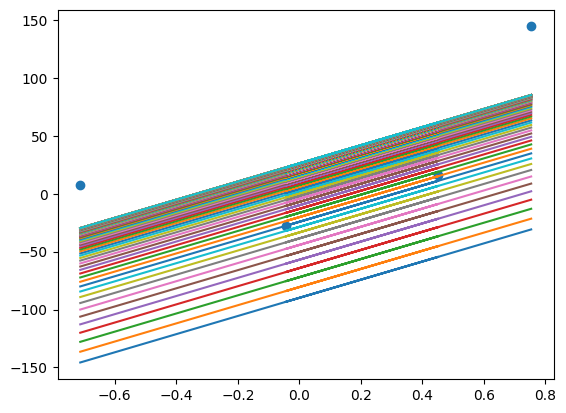

In [81]:
#lets build a loop
b=-100
m=78.35
lr=0.01
epoches=100

for i in range(epoches):
    loss_slope=-2*np.sum(y-m*x.ravel()-b)
    b=b-lr*loss_slope
    y_pred=m*x+b
    plt.plot(x,y_pred)
plt.scatter(x,y)
